In [1]:
import sys
from pathlib import Path

from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import graphviz as gpv

In [2]:
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

In [3]:
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

In [4]:
from src.pipeline import SlobPipeline
from src.config import RunConfig
from src.modules.model_factory import Model
from src.modules.artifacts import Artifacts

In [5]:
def plot_tree(
    model: Model, 
    config: RunConfig,
    tree_idx=0,
    condition_node_color="#2C3E50",
    leaf_node_color="#27AE60",
    edge_color_yes="#2980B9",
    edge_color_no="#C0392B",
):
    booster = model.get_booster() if hasattr(model, "get_booster") else model
    graph = xgb.to_graphviz(
        booster,
        tree_idx=tree_idx,
        condition_node_params={
            "shape": "box",
            "style": "filled,rounded",
            "fillcolor": condition_node_color,
            "fontcolor": "white",
        },
        leaf_node_params={
            "shape": "box",
            "style": "filled,rounded",
            "fillcolor": leaf_node_color,
            "fontcolor": "white",
        },
    )

    dot_source = graph.source

    dot_source = dot_source.replace(
        'color="#FF0000"', f'color="{edge_color_yes}" penwidth=2'
    ).replace(
        'color="#0000FF"', f'color="{edge_color_no}" penwidth=2'
    )

    graph_attrs = (
        f'graph [ rankdir=LR size="20,15" dpi=300 '
        f'ranksep=0.5 nodesep=0.3 bgcolor=white ]')
    dot_source = dot_source.replace(dot_source.split("\n")[1], f"{graph_attrs}")
    graph_ = gpv.Source(dot_source, format='png')
    artifacts = Artifacts(config=config)
    
    graph_.render(filename=artifacts.trains_plot_dir / f'{config.run_name}_tree', cleanup=True)
    return graph_


=== Training classification_no_abc_h4 ===
[classification_no_abc_h4] reusing cached artifacts from C:\Users\Daisy\Desktop\all desktop\Deskstop\Thesis\Daisy\slob-forecasting\artifacts\runs\models\classification_no_abc_h4
{'accuracy': 0.9998034398034398, 'precision': 1.0, 'recall': 0.9996270743986575, 'f1': 0.9998135024244685, 'roc_auc': 0.9999712841668282}


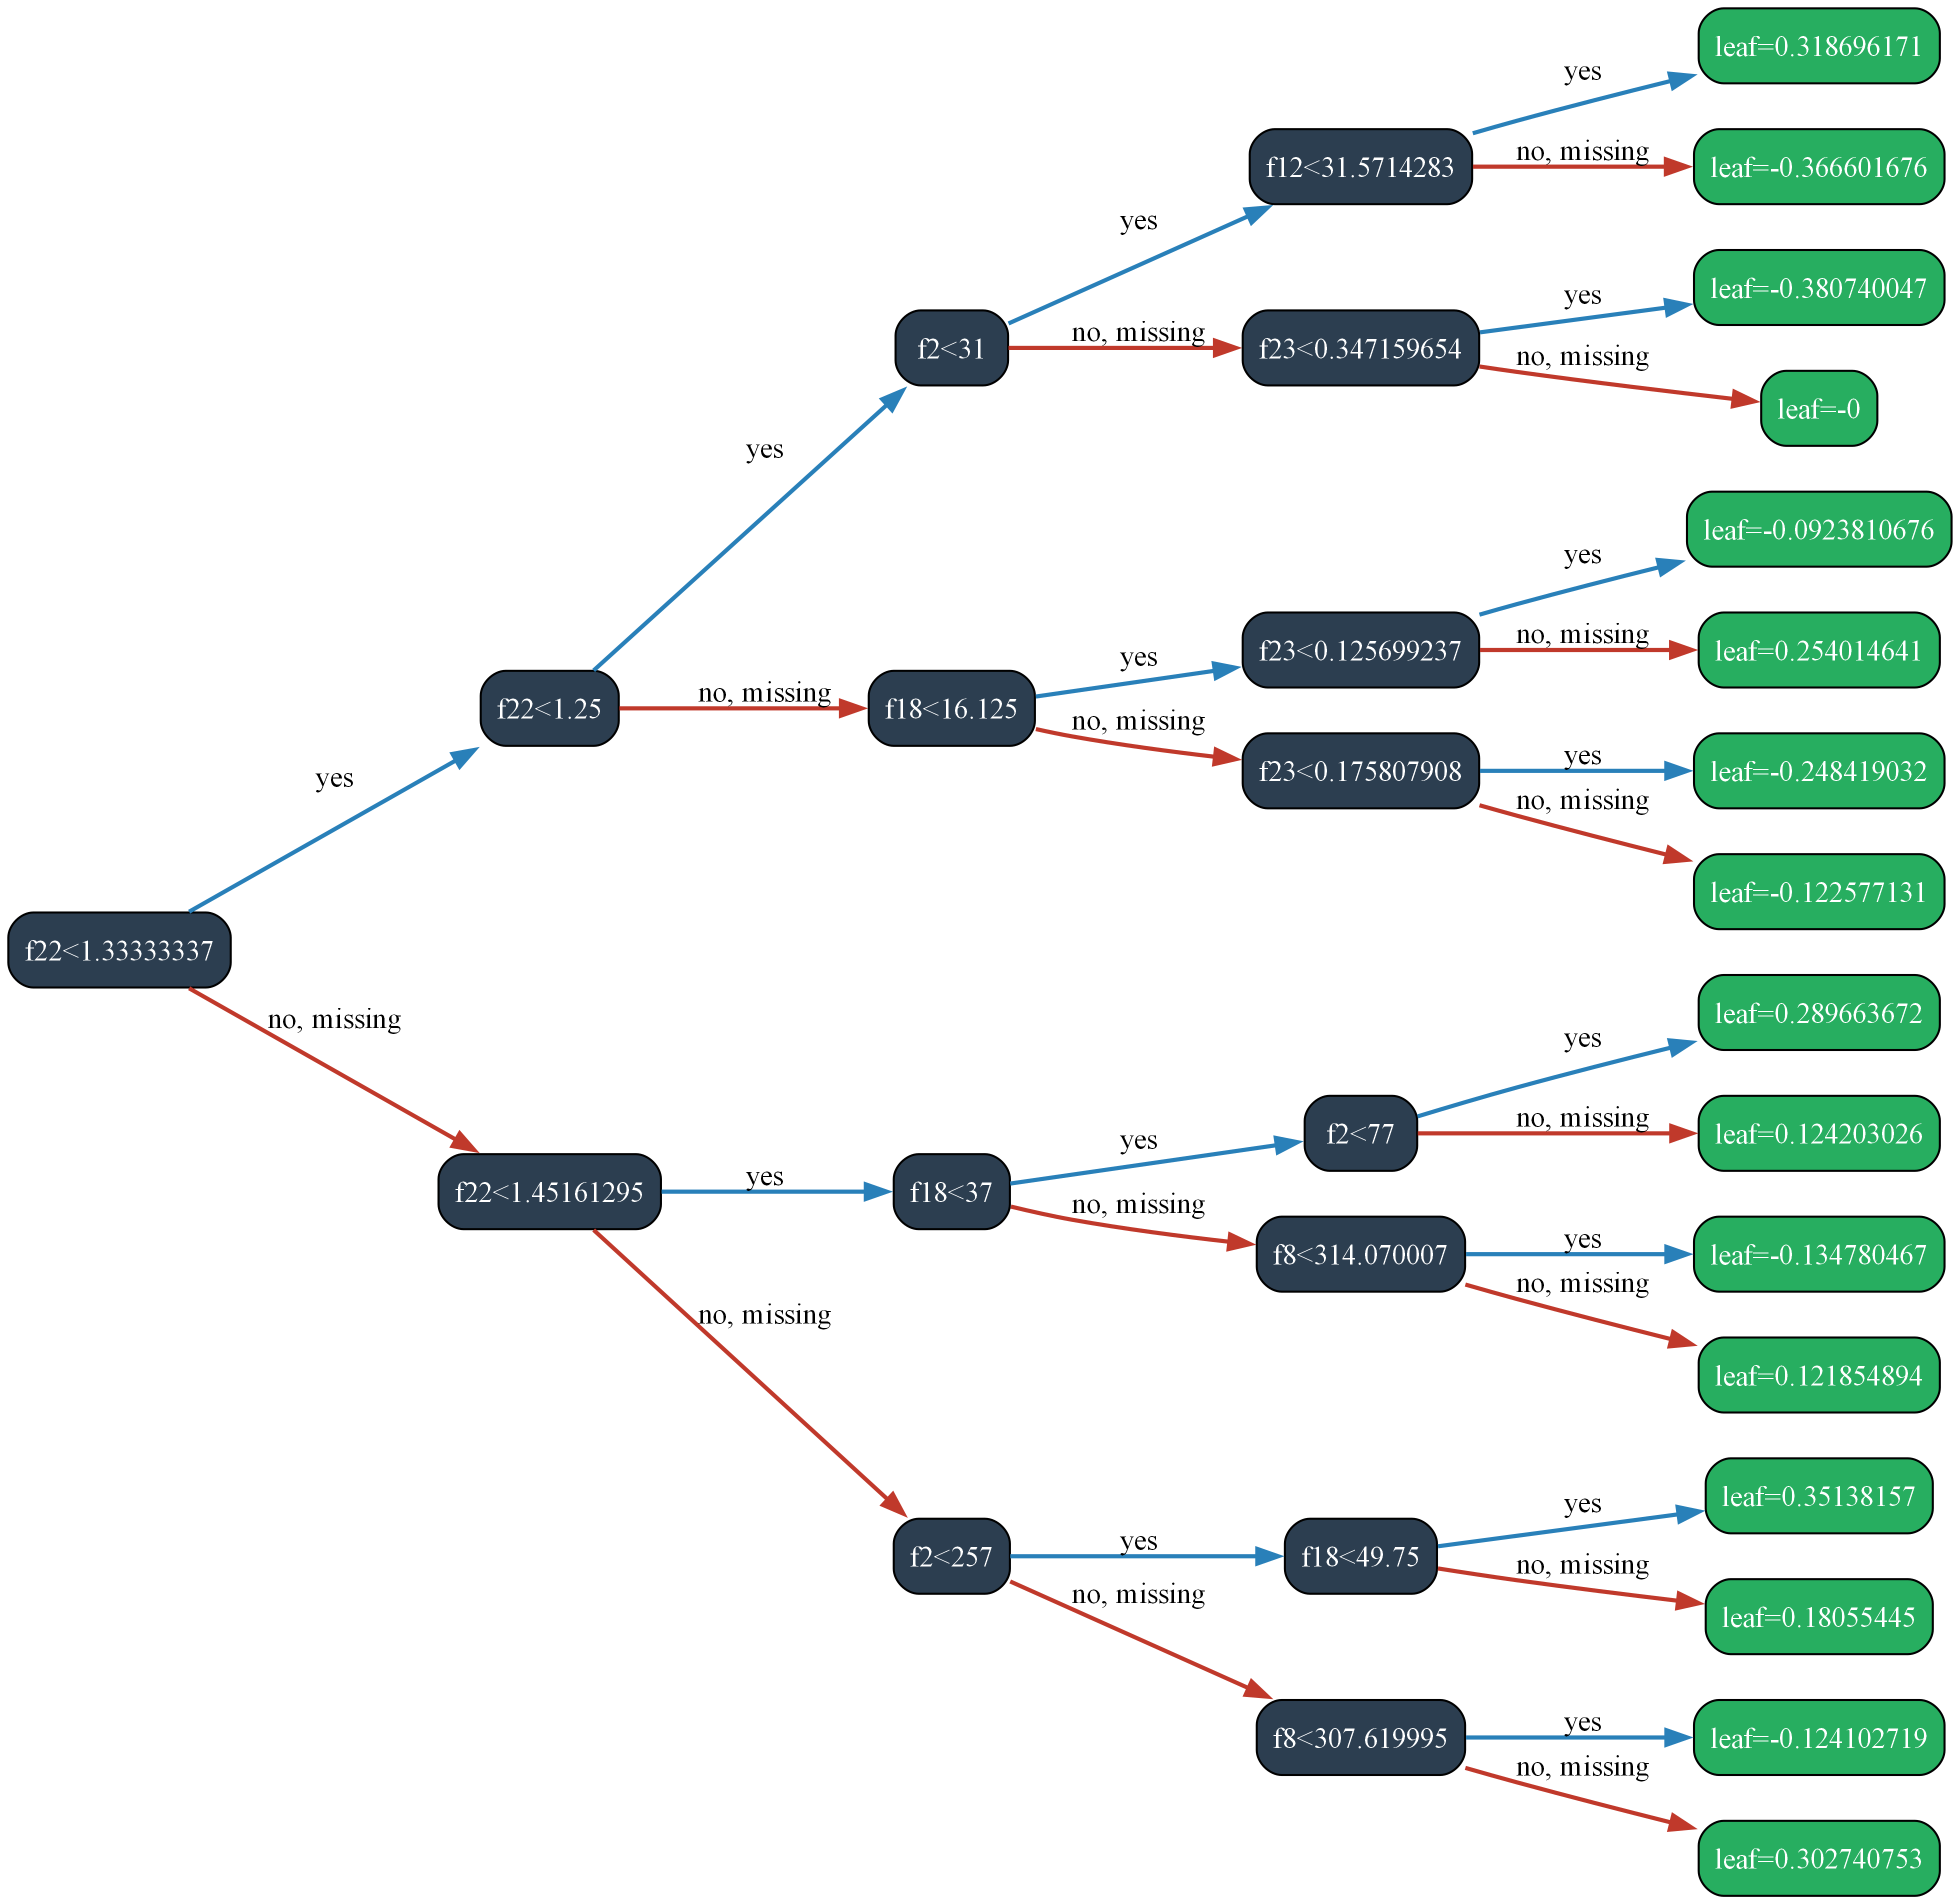


=== Training regression_no_abc_h4 ===
[regression_no_abc_h4] reusing cached artifacts from C:\Users\Daisy\Desktop\all desktop\Deskstop\Thesis\Daisy\slob-forecasting\artifacts\runs\models\regression_no_abc_h4
{'rmse': 73.75651188444682, 'mae': 38.63716345730812, 'r2': 0.6326749671873626}


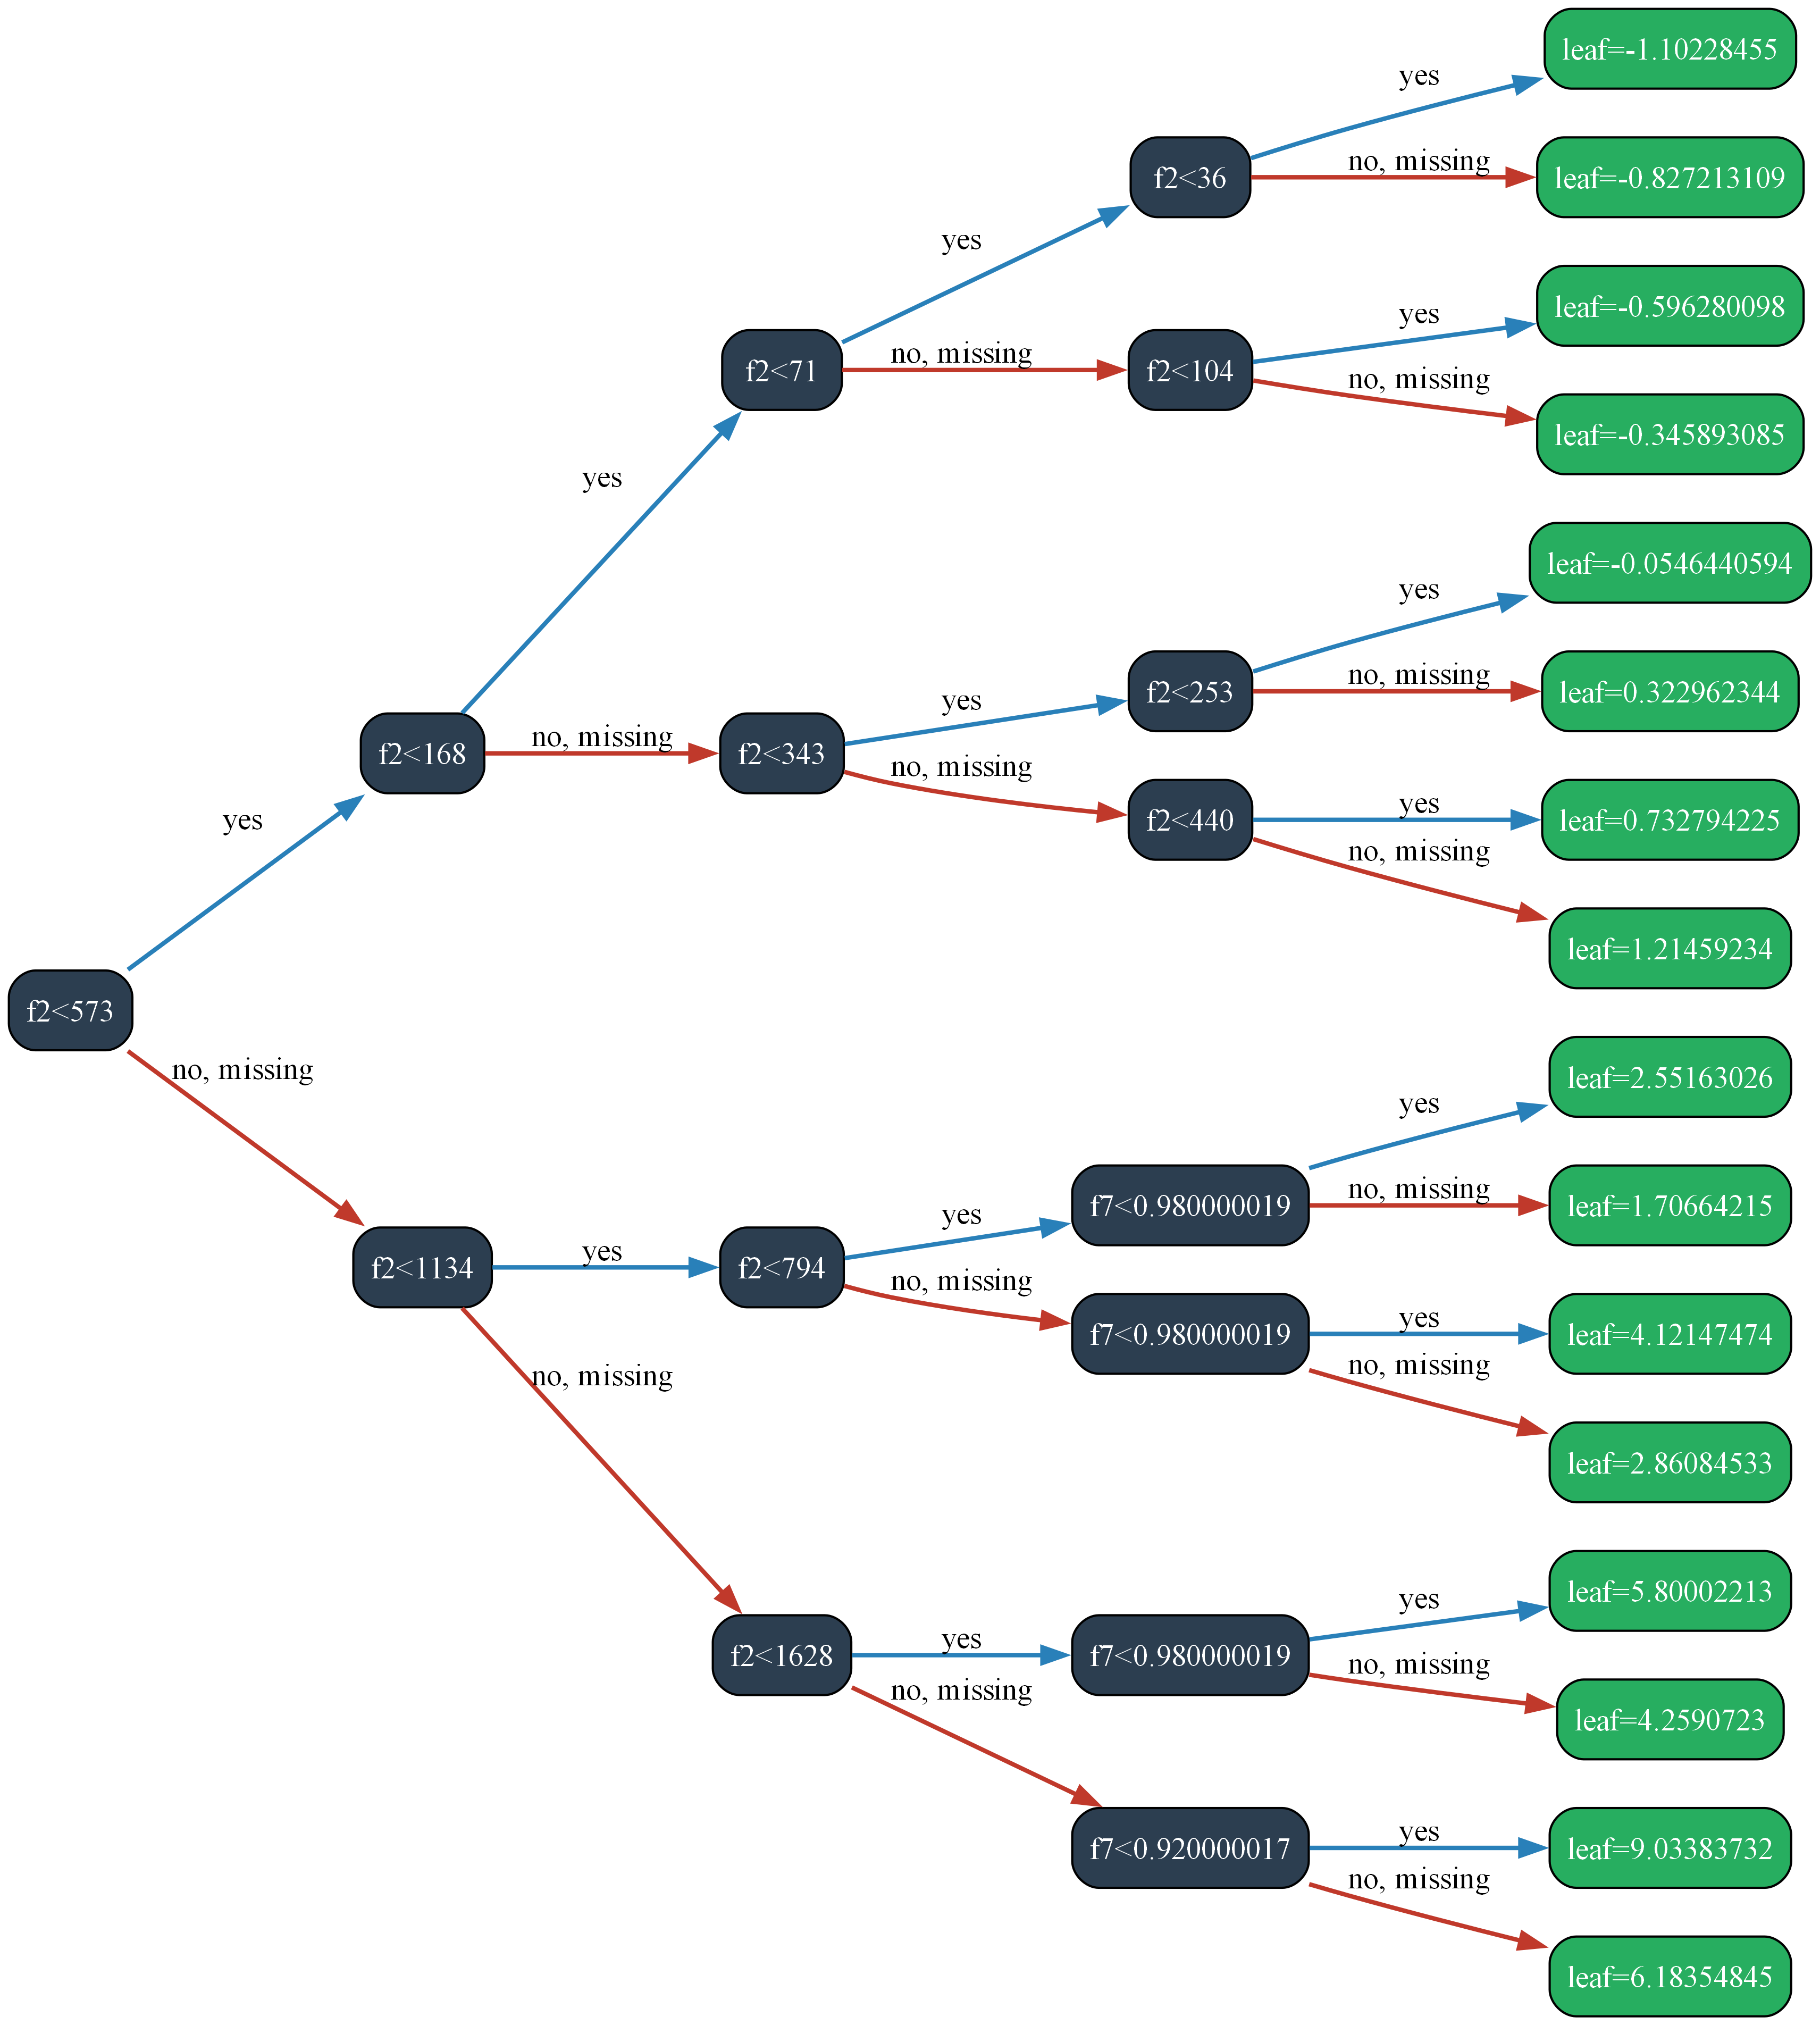

In [6]:
results = {}
for task in ("classification", "regression"):
    config = RunConfig(task=task, include_abc=False,)
    print(f"\n=== Training {config.run_name} ===")
    slob_pipeline = SlobPipeline(config=config)
    results[config.run_name] = slob_pipeline.run_or_load(verbose=True)
    m = results[config.run_name]["result"]["test_metrics"]
    print({k: v for k, v in m.items() if k != "confusion_matrix"})
    tree = plot_tree(model=slob_pipeline.model_, config=config)
    display(Image(tree.pipe(format='png')))